# Regression

* What is a regression
    * Analyze relationship between variables
* Why do we perform regression
    * Prediction, Explanation, Relationship analysis, trend analysism control
* Types of regression
    * Linear, Non linear, regularized regression. logistic, specialized
* Sample datatable for each type of regression

Intercept: 50.00
Slope: 5.00
R-squared: 1.00
Mean Squared Error: 0.00


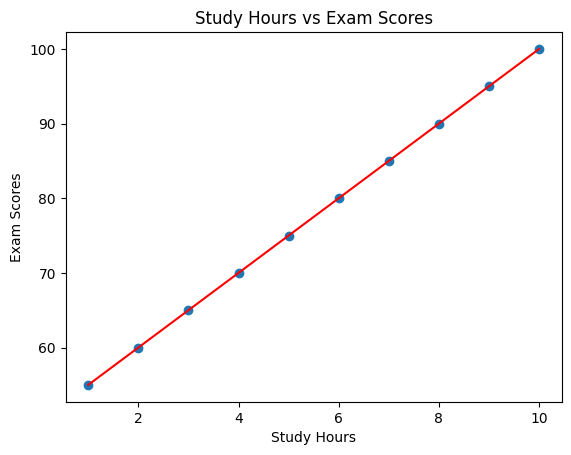

In [14]:
# Create Data frame
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#import data
data = pd.read_csv('linear_regression.csv')
df = pd.DataFrame(data)
# Reshape and Rename the data

df = df.rename(columns={"X (Study Hours)": "Study Hours", "Y (Exam Score)": "Scores"})

df.head()
x = df[["Study Hours"]]
y = df["Scores"]


# Create a linear regression model
model = LinearRegression()
model.fit(x, y)

# predict the scores
y_pred = model.predict(x)

#print Coefficients
print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")
print(f"R-squared: {r2_score(y, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred):.2f}")

# Create a scatter plot
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')  # Add the regression line
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Study Hours vs Exam Scores")
plt.show()



## Non Linear Regression

R-squared: 1.00
Mean Squared Error: 0.00
Coefficients: [0. 2. 1.]
Intercept: 3.00


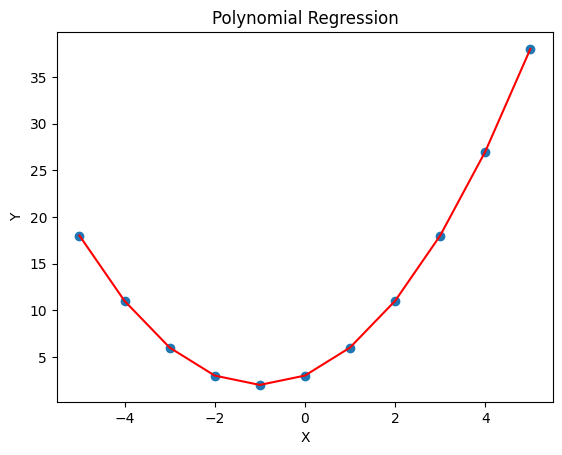

,X,Y
0,-5,18
1,-4,11
2,-3,6
3,-2,3
4,-1,2


In [24]:
data = pd.read_csv("nonlinear_regression.csv")
df = pd.DataFrame(data)

df.rename(columns={"Y (Quadratic Relationship)": "Y"}, inplace=True)
x = df[["X"]]
y = df["Y"]

#Transform the data to include polynomial features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

#fit the model
model = LinearRegression()
model.fit(x_poly, y)
df.head()
y_predict = model.predict(x_poly)

print(f"R-squared: {r2_score(y, y_predict):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y, y_predict):.2f}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.2f}")

#Plot Data
plt.scatter(x, y)
plt.plot(x, y_predict, color='red')
plt.xlabel("X") 
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.show()
df.head()

## Logistic Regression


In [29]:
    
# Load your data
from sklearn.linear_model import LogisticRegression


data = pd.read_csv("logistic_regression.csv")

X = data[["X (Hours)"]]
y = data["Y (Pass=1, Fail=0)"]

# Create model
model = LogisticRegression()

# Train model
model.fit(X, y)

# Predictions (probabilities)
probs = model.predict_proba(X)

# Predictions (0 or 1)
preds = model.predict(X)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Predictions:", preds)

Coefficients: [[1.14647778]]
Intercept: [-3.9914817]
Predictions: [0 0 0 1 1 1 1]


In [ ]:
data = pd.read_csv('regularized_regression.csv')
df = pd.DataFrame(data)

x = df[["Feature1", "Feature2", "Feature3"]]
y = df["Target"]

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

df.head()

,Feature1,Feature2,Feature3,Target
0,1,2,3,10
1,2,3,4,14
2,3,4,5,18
3,4,5,6,22
4,5,6,7,26


In [30]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split


np.random.seed(42)

n = 100

data = pd.DataFrame({
    "feature1": np.random.randn(n),
    "feature2": np.random.randn(n),
    "feature3": np.random.randn(n),
})

# True relationship (only feature1 + feature2 matter)
data["target"] = (
    3 * data["feature1"]
    + 2 * data["feature2"]
    + np.random.randn(n) * 0.5
)

print(data.head())

X = data[["feature1", "feature2", "feature3"]]
y = data["target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

# Train
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Results
print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients:", lasso.coef_)

from sklearn.metrics import mean_squared_error

ridge_preds = ridge.predict(X_test)
lasso_preds = lasso.predict(X_test)

print("Ridge MSE:", mean_squared_error(y_test, ridge_preds))
print("Lasso MSE:", mean_squared_error(y_test, lasso_preds))

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=0.1))

ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

   feature1  feature2  feature3    target
0  0.496714 -1.415371  0.357787 -1.755097
1 -0.138264 -0.420645  0.560785 -1.536174
2  0.647689 -0.342715  1.083051  1.631283
3  1.523030 -0.802277  1.053802  3.269720
4 -0.234153 -0.161286 -1.377669 -1.035482
Ridge Coefficients: [2.85125041 1.93226195 0.0245613 ]
Lasso Coefficients: [2.75555926 1.83727924 0.        ]
Ridge MSE: 0.22704291062706092
Lasso MSE: 0.27289960376554034


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1))])